# 02 — Small CNN (from scratch)

In [1]:
import sys
import time
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from pathlib import Path

from eval import LABEL_ORDER
from utils import (
    set_seed, load_dataset, split_dataset,
    get_train_transform, get_eval_transform, build_dataloaders,
    train_model, save_checkpoint, load_checkpoint,
    plot_training_history, print_model_info,
    compute_multilabel_metrics, evaluate_predictor,
    print_metric_table, NUM_LABELS, METRIC_KEYS,
)

SEED = 42
set_seed(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"Labels ({NUM_LABELS}): {LABEL_ORDER}")


Device: cuda
Labels (12): ['pen', 'paper', 'book', 'clock', 'phone', 'laptop', 'chair', 'desk', 'bottle', 'keychain', 'backpack', 'calculator']


In [2]:
BASE_DIR        = "../data/aggregated"
IMAGE_SIZE      = 128
BATCH_SIZE      = 128
SPLIT           = [0.7, 0.15, 0.15]
CHECKPOINT_DIR  = Path("../checkpoints")
EXPERIMENT_NAME = "small_cnn"
MODEL_PATH      = CHECKPOINT_DIR / f"final_{EXPERIMENT_NAME}.pth"

full_dataset = load_dataset(BASE_DIR)
train_raw, val_raw, test_raw = split_dataset(full_dataset, SPLIT, SEED)

train_transform = get_train_transform(IMAGE_SIZE)
eval_transform  = get_eval_transform(IMAGE_SIZE)
train_loader, val_loader, test_loader = build_dataloaders(
    train_raw, val_raw, test_raw, train_transform, eval_transform,
    batch_size=BATCH_SIZE,
)
print(f"Train: {len(train_raw)}  |  Val: {len(val_raw)}  |  Test: {len(test_raw)}")


Train: 3180  |  Val: 681  |  Test: 682


## Model Definition

In [3]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding="same"), nn.BatchNorm2d(16), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding="same"), nn.BatchNorm2d(32), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding="same"), nn.BatchNorm2d(64), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding="same"), nn.BatchNorm2d(128), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 512), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(512, 128), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.classifier(self.features(x))

def create_model(num_labels):
    return SmallCNN(num_classes=num_labels)

print_model_info(create_model(NUM_LABELS))


  Total params     :    4,359,948
  Trainable params :    4,359,948  (100.0%)
  Model size       : 16.63 MB  (float32 weights)


## Grid Search (LR × WD)

In [4]:
GRID = [
    {"lr": 1e-3, "wd": 1e-4},
    {"lr": 1e-3, "wd": 1e-3},
    {"lr": 3e-4, "wd": 1e-4},
    {"lr": 1e-4, "wd": 1e-4},
]

grid_results = []
for cfg in GRID:
    print(f"\n--- lr={cfg['lr']:.0e}  wd={cfg['wd']:.0e} ---")
    state, val_f1, _, epochs_run = train_model(
        create_model, NUM_LABELS, train_loader, val_loader, DEVICE,
        lr=cfg["lr"], weight_decay=cfg["wd"],
        max_epochs=20, warmup_epochs=2, early_stop_patience=5,
    )
    grid_results.append({**cfg, "val_f1": val_f1, "state": state, "epochs": epochs_run})
    print(f"  => val F1: {val_f1:.4f}")

grid_results.sort(key=lambda x: x["val_f1"], reverse=True)
best = grid_results[0]
print(f"\nBest config: lr={best['lr']:.0e}  wd={best['wd']:.0e}  val_F1={best['val_f1']:.4f}")

rows = [{"lr": c["lr"], "wd": c["wd"], "val_f1": round(c["val_f1"], 4), "epochs": c["epochs"]}
        for c in grid_results]
print(pd.DataFrame(rows).to_string(index=False))



--- lr=1e-03  wd=1e-04 ---

Epoch  1/20  [lr=5.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.6027    0.4360
  exact_match            0.0151    0.0059
  hamming_acc            0.7813    0.8513
  mean_iou               0.0698    0.0113
  precision_micro        0.1591    0.3171
  recall_micro           0.1147    0.0108
  f1_micro               0.1333    0.0210

Epoch  2/20  [lr=1.00e-03]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4476    0.4086
  exact_match            0.0173    0.0029
  hamming_acc            0.8379    0.8529
  mean_iou               0.0398    0.0037
  precision_micro        0.2209    0.3750
  recall_micro           0.0416    0.0025
  f1_micro               0.0701    0.0050

Epoch  3/20  [lr=1.00e-03]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4329    0.4136
  e

## Final Training


Epoch  1/60  [lr=2.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.5517    0.4363
  exact_match            0.0126    0.0000
  hamming_acc            0.7844    0.8523
  mean_iou               0.0565    0.0007
  precision_micro        0.1513    0.1111
  recall_micro           0.1020    0.0008
  f1_micro               0.1219    0.0017

Epoch  2/60  [lr=4.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4585    0.4167
  exact_match            0.0189    0.0176
  hamming_acc            0.8315    0.8549
  mean_iou               0.0455    0.0218
  precision_micro        0.2065    0.8182
  recall_micro           0.0524    0.0150
  f1_micro               0.0835    0.0295

Epoch  3/60  [lr=6.00e-04]
  Metric                  Train       Val
  ----------------------------------------
  loss                   0.4358    0.4040
  exact_match            0.0245

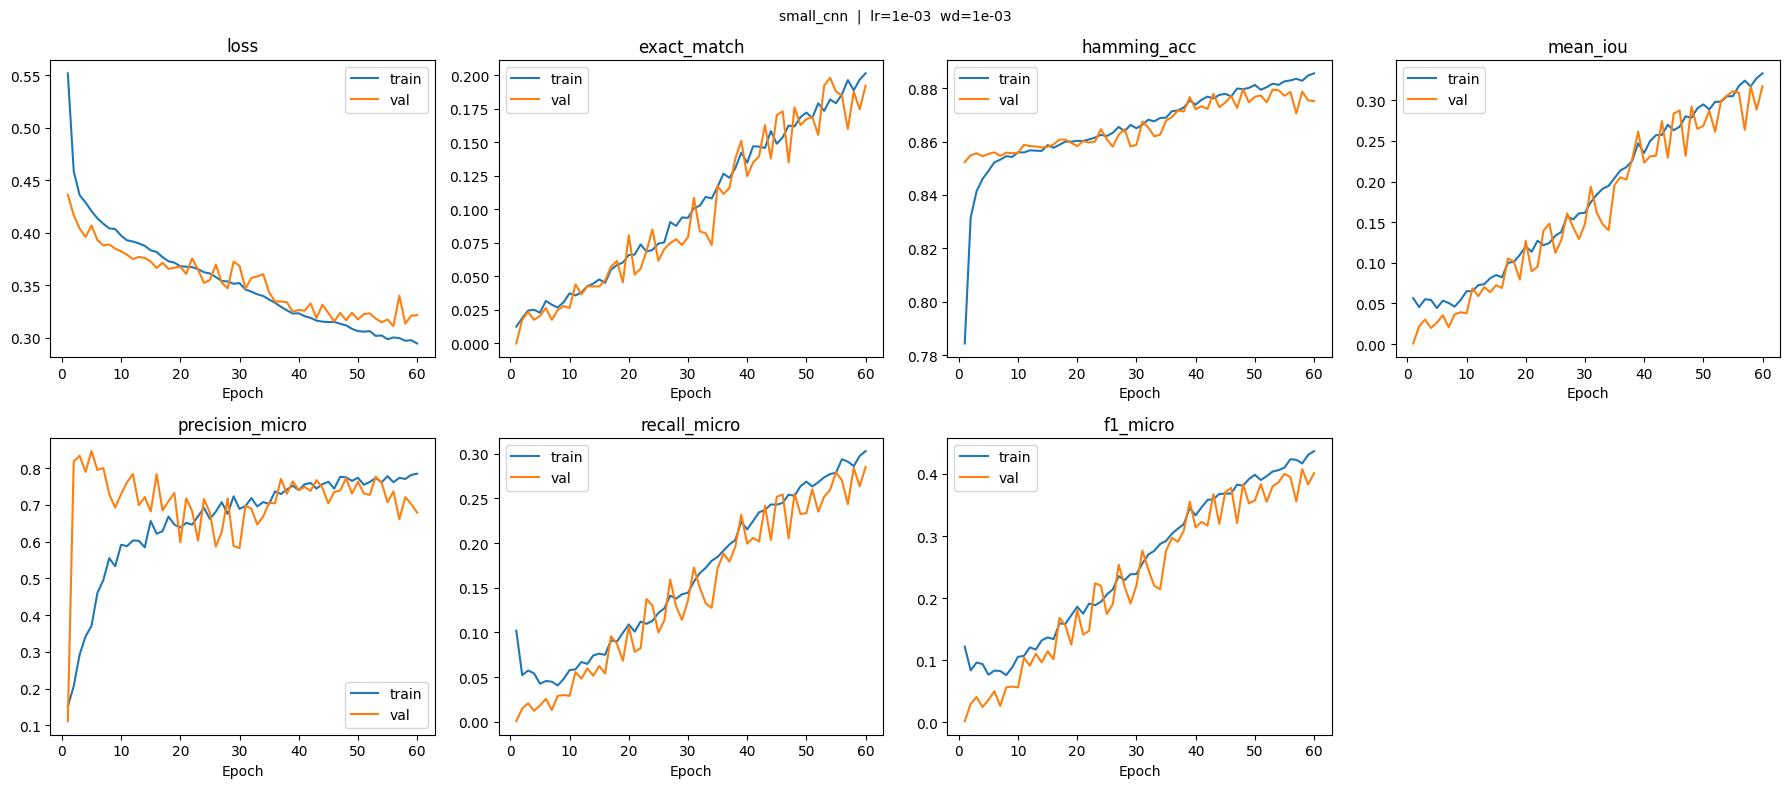

In [5]:
t0 = time.time()
best_state, best_val_f1, history, epochs_run = train_model(
    create_model, NUM_LABELS, train_loader, val_loader, DEVICE,
    lr=best["lr"], weight_decay=best["wd"],
    max_epochs=60, warmup_epochs=5, early_stop_patience=10,
)
training_time = time.time() - t0
print(f"\nBest val F1: {best_val_f1:.4f}  |  Epochs: {epochs_run}  |  Time: {training_time:.1f}s")

save_checkpoint(best_state, MODEL_PATH)
plot_training_history(history, epochs_run, EXPERIMENT_NAME, best["lr"], best["wd"])


## Evaluation

In [6]:
model = load_checkpoint(create_model, NUM_LABELS, MODEL_PATH, DEVICE)
model.eval()

def _predict(images, threshold=0.5):
    with torch.no_grad():
        logits = model(images)
        probs  = torch.sigmoid(logits)
        preds  = (probs >= threshold).float()
    return preds, probs, logits

val_metrics  = evaluate_predictor(val_loader,  _predict, DEVICE)
test_metrics = evaluate_predictor(test_loader, _predict, DEVICE)

rows = [
    {"split": "val",  **{k: round(val_metrics[k],  4) for k in METRIC_KEYS}},
    {"split": "test", **{k: round(test_metrics[k], 4) for k in METRIC_KEYS}},
]
df = pd.DataFrame(rows).set_index("split")
print(df.to_string())


         loss  exact_match  hamming_acc  mean_iou  precision_micro  recall_micro  f1_micro
split                                                                                     
val    0.3136       0.1880       0.8787    0.3171           0.7209        0.2842    0.4077
test   0.3117       0.2053       0.8805    0.3303           0.7187        0.2939    0.4172


In [7]:

print("\nModel summary:")
print_model_info(create_model(NUM_LABELS))
print(f"Training time : {training_time:.1f}s")



Model summary:
  Total params     :    4,359,948
  Trainable params :    4,359,948  (100.0%)
  Model size       : 16.63 MB  (float32 weights)
Training time : 250.7s
